# Deep SARSA Snake Model Analysis
This notebook analyzes the performance and decision-making of the trained **Deep SARSA** agent for the Snake game.
It includes:
- Evaluation over multiple episodes  
- Analytical graphs (score, moving average, reward distribution)  
- Decision-making graphs (action frequency, Q-value distribution)


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os
import importlib, snake_deep_sarsa
importlib.reload(snake_deep_sarsa)

# Import your Deep SARSA implementation
from snake_deep_sarsa import SnakeGame, SARSAAgent, GRID_SIZE, MODEL_PATH

# Set up environment and load trained agent
env = SnakeGame(grid_size=GRID_SIZE)
agent = SARSAAgent()
agent.model.load_state_dict(torch.load(MODEL_PATH))
agent.model.eval()


DQN(
  (fc1): Linear(in_features=16, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=256, bias=True)
  (fc4): Linear(in_features=256, out_features=3, bias=True)
  (dropout): Dropout(p=0.05, inplace=False)
)

In [2]:
num_episodes = 1000
scores, rewards = [], []
actions_all, q_values_all = [], []

for ep in range(num_episodes):
    state = env.reset()
    done = False
    total_reward = 0
    actions = []
    q_vals = []

    while not done:
        state_t = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q_values = agent.model(state_t).squeeze().numpy()
        action = np.argmax(q_values)

        actions.append(action)
        q_vals.append(q_values)

        next_state, reward, done = env.step(action)
        total_reward += reward
        state = next_state

    scores.append(env.score)
    rewards.append(total_reward)
    actions_all.extend(actions)
    q_values_all.extend(q_vals)

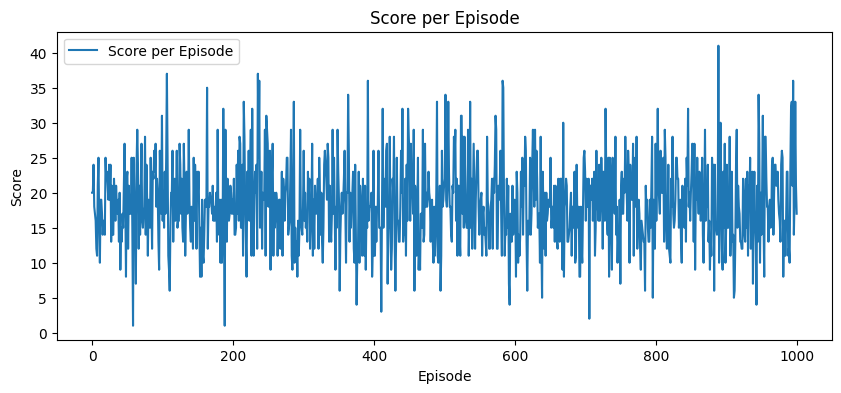

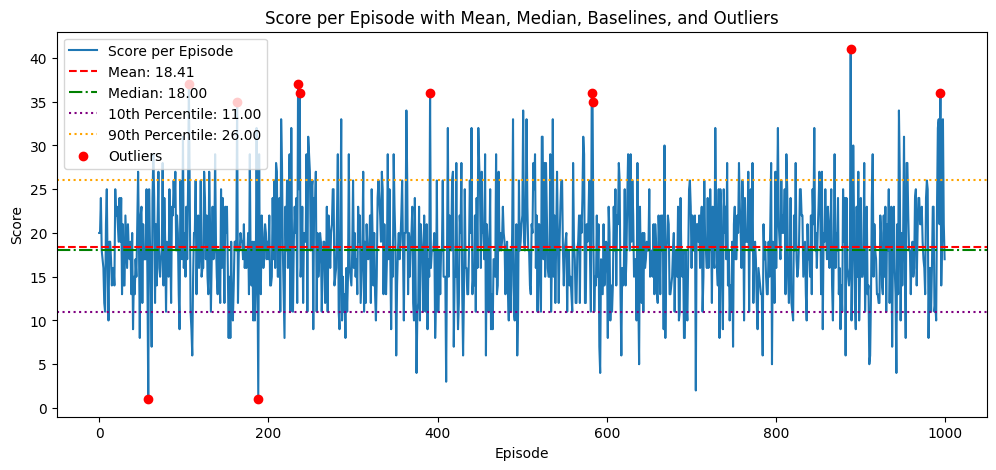

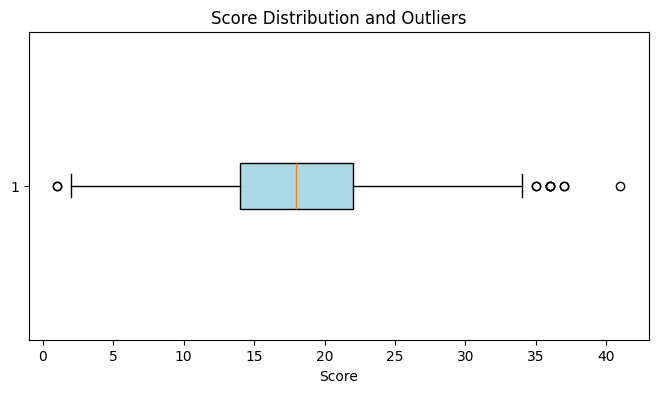

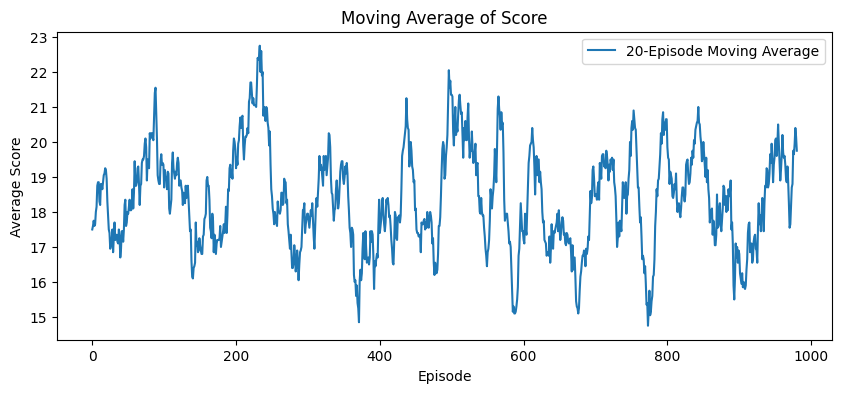

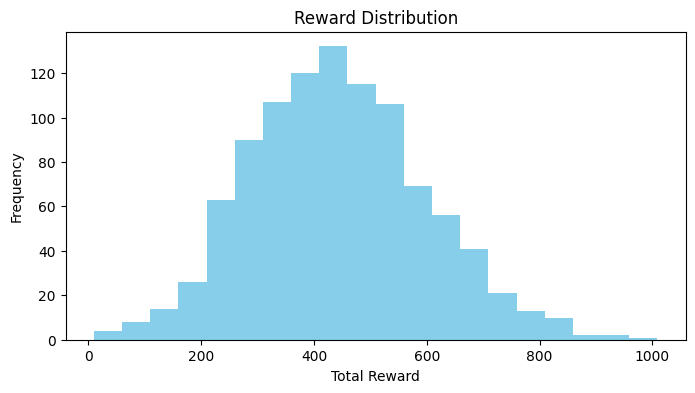

In [3]:
# --- Score per episode ---
plt.figure(figsize=(10,4))
plt.plot(scores, label='Score per Episode')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.title('Score per Episode')
plt.legend()
plt.show()

# ==============================

# ===
mean_score = np.mean(scores)
median_score = np.median(scores)
lower_baseline = np.percentile(scores, 10)
upper_baseline = np.percentile(scores, 90)
q1 = np.percentile(scores, 25)
q3 = np.percentile(scores, 75)
iqr = q3 - q1
lower_outlier = q1 - 1.5 * iqr
upper_outlier = q3 + 1.5 * iqr

outlier_indices = [i for i, s in enumerate(scores) if s < lower_outlier or s > upper_outlier]
outlier_scores = [scores[i] for i in outlier_indices]

plt.figure(figsize=(12,5))
plt.plot(scores, label='Score per Episode')
plt.axhline(mean_score, color='red', linestyle='--', label=f'Mean: {mean_score:.2f}')
plt.axhline(median_score, color='green', linestyle='-.', label=f'Median: {median_score:.2f}')
plt.axhline(lower_baseline, color='purple', linestyle=':', label=f'10th Percentile: {lower_baseline:.2f}')
plt.axhline(upper_baseline, color='orange', linestyle=':', label=f'90th Percentile: {upper_baseline:.2f}')
plt.scatter(outlier_indices, outlier_scores, color='red', label='Outliers', zorder=5)
plt.xlabel('Episode')
plt.ylabel('Score')
plt.title('Score per Episode with Mean, Median, Baselines, and Outliers')
plt.legend()
plt.show()

# ===
plt.figure(figsize=(8,4))
plt.boxplot(scores, vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.xlabel('Score')
plt.title('Score Distribution and Outliers')
plt.show()

# ==============================

# --- Moving average of scores ---
window = 20
moving_avg = np.convolve(scores, np.ones(window)/window, mode='valid')
plt.figure(figsize=(10,4))
plt.plot(moving_avg, label=f'{window}-Episode Moving Average')
plt.xlabel('Episode')
plt.ylabel('Average Score')
plt.title('Moving Average of Score')
plt.legend()
plt.show()

# --- Reward distribution ---
plt.figure(figsize=(8,4))
plt.hist(rewards, bins=20, color='skyblue')
plt.xlabel('Total Reward')
plt.ylabel('Frequency')
plt.title('Reward Distribution')
plt.show()


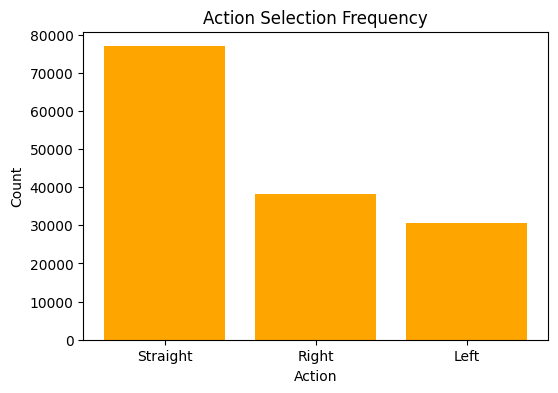

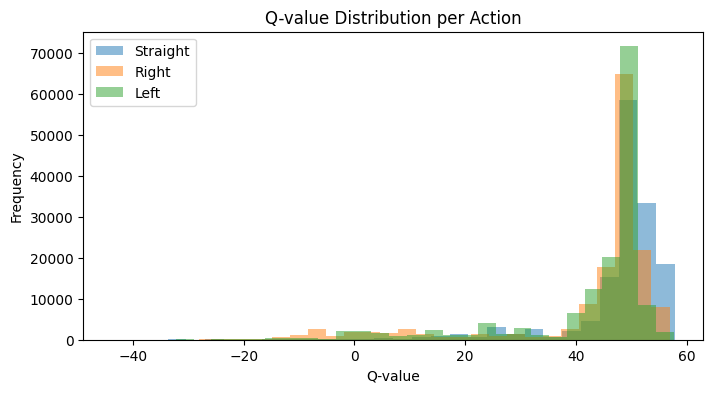

In [4]:
# --- Action selection frequency ---
action_counts = Counter(actions_all)
actions = ['Straight', 'Right', 'Left']
counts = [action_counts.get(i, 0) for i in range(3)]

plt.figure(figsize=(6,4))
plt.bar(actions, counts, color='orange')
plt.xlabel('Action')
plt.ylabel('Count')
plt.title('Action Selection Frequency')
plt.show()

# --- Q-value distributions ---
q_values_all = np.array(q_values_all)
plt.figure(figsize=(8,4))
for i, action in enumerate(actions):
    plt.hist(q_values_all[:, i], bins=30, alpha=0.5, label=action)
plt.xlabel('Q-value')
plt.ylabel('Frequency')
plt.title('Q-value Distribution per Action')
plt.legend()
plt.show()


### Summary
- The graphs above show how the Deep SARSA agent behaves after training.  
- **Score / Reward trends** reveal consistency or volatility.  
- **Action frequency and Q-value distributions** explain the agent’s learned policy preferences.
